# Analisi Salariale
**Obiettivo:** Analizzare il dataset dei salari per capire le relazioni tra le variabili e prevedere il salario usando modelli di regressione.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
df = pd.read_csv("../data/raw/salary_prediction_data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


# Analisi Esplorativa dei Dati (EDA)
In questa sezione esploreremo il dataset per capire la distribuzione delle variabili, la presenza di valori mancanti e le relazioni tra le feature e il salario.

## Struttura del dataset
Verifichiamo il numero di righe, colonne e tipi di dati.

In [3]:
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    str    
 2   Education Level      373 non-null    str    
 3   Job Title            373 non-null    str    
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 17.7 KB


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
count,373.000000,373,373,373,373.000000,373.000000
unique,NaN,2,3,174,NaN,NaN
top,NaN,Male,Bachelor's,Director of Marketing,NaN,NaN
freq,NaN,194,224,12,NaN,NaN
mean,37.431635,NaN,NaN,NaN,10.030831,100577.345845
std,7.069073,NaN,NaN,NaN,6.557007,48240.013482
min,23.000000,NaN,NaN,NaN,0.000000,350.000000
25%,31.000000,NaN,NaN,NaN,4.000000,55000.000000
50%,36.000000,NaN,NaN,NaN,9.000000,95000.000000
75%,44.000000,NaN,NaN,NaN,15.000000,140000.000000


## Valori mancanti
Vediamo se ci sono valori nulli o assenti nel dataset.

In [4]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

## Distribuzione del salario
Analizziamo come sono distribuiti i salari nel dataset.

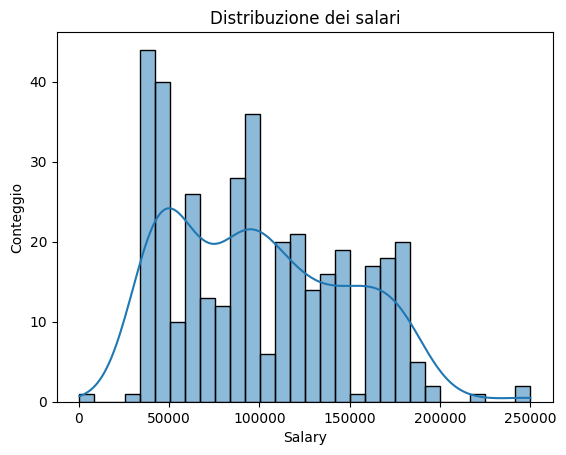

In [5]:
sns.histplot(df['Salary'], bins=30, kde=True)
plt.title("Distribuzione dei salari")
plt.xlabel("Salary")
plt.ylabel("Conteggio")
plt.show()

## Correlazioni tra variabili numeriche
Controlliamo quali variabili numeriche sono più correlate con il salario usando la correlazione di Pearson.

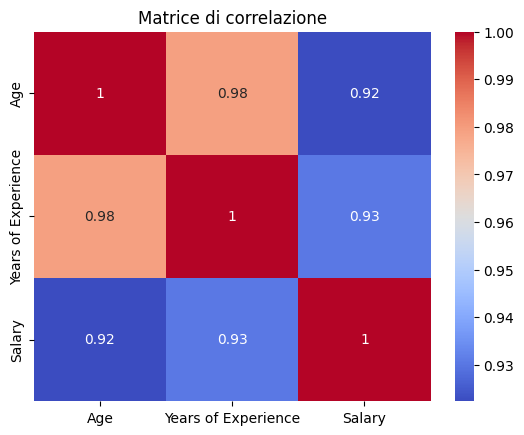

In [ ]:
numeric_cols = df._get_numeric_data()
corr = numeric_cols.corr() # Ignora automaticamente i NaN
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matrice di correlazione")
plt.show()

## Analisi delle variabili categoriche
Vediamo come le variabili categoriali (es. Education Level, Job Title, Gender) influenzano il salario.

Education Level
Bachelor's    224
Master's       98
PhD            51
Name: count, dtype: int64


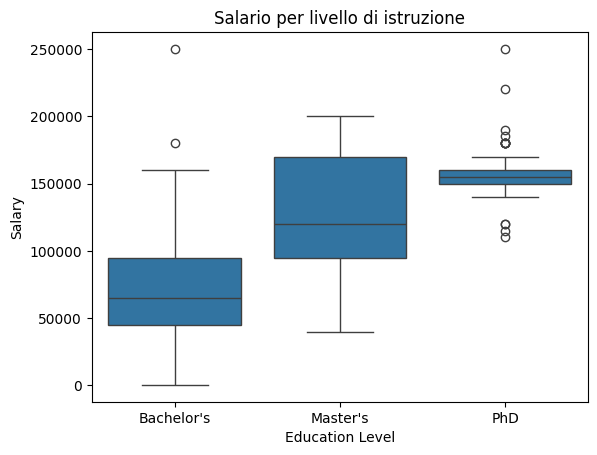

In [8]:
# Controllo frequenze
print(df['Education Level'].value_counts())

# Boxplot per capire la relazione con il salario
sns.boxplot(x='Education Level', y='Salary', data=df)
plt.title("Salario per livello di istruzione")
plt.show()

Vediamo che le due categorie Bachelor's e PhD hanno degli outliers, quindi individuiamoli utilizzando il metodo IQR.

In [9]:
# Lista per salvare gli outlier
outliers = pd.DataFrame()

# Itera su ogni livello di istruzione
for level in df['Education Level'].unique():
    salaries = df[df['Education Level'] == level]['Salary']
    Q1 = salaries.quantile(0.25)
    Q3 = salaries.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Seleziona gli outlier per questo livello
    outliers_level = df[(df['Education Level'] == level) & 
                        ((df['Salary'] < lower_bound) | (df['Salary'] > upper_bound))]
    
    outliers = pd.concat([outliers, outliers_level])

# Visualizza gli outlier trovati
print(outliers["Education Level"].value_counts(), "\n")
print(outliers)

Education Level
PhD           14
Bachelor's     2
Name: count, dtype: int64 

      Age  Gender Education Level                        Job Title  \
19   51.0    Male      Bachelor's                   Sales Director   
30   50.0    Male      Bachelor's                              CEO   
9    38.0    Male             PhD                 Senior Scientist   
17   39.0    Male             PhD                  Senior Engineer   
48   38.0    Male             PhD                 Senior Scientist   
63   47.0    Male             PhD            Senior Data Scientist   
72   45.0    Male             PhD                Research Director   
83   52.0    Male             PhD         Chief Technology Officer   
90   36.0    Male             PhD              Principal Scientist   
105  44.0    Male             PhD               Chief Data Officer   
158  51.0  Female             PhD      Director of Human Resources   
188  50.0  Female             PhD  Director of Sales and Marketing   
217  50.0  F

## Osservazioni
- Più alto il livello di istruzione, più alto tende a essere il salario mediano.
- La variabilità del salario è maggiore per i Master's e Bachelor's rispetto ai PhD.
- Ci sono outlier evidenti, soprattutto nei Bachelor's e PhD, quindi alcuni salari estremi influenzano la distribuzione.

--> Dunque l’**istruzione** è una variabile importante per predire il salario.

Calcoliamo per ogni "Educational level" la media/la mediana e la deviazione standard.

In [10]:
df_group = df[["Education Level", "Salary"]]
df_group = df_group.groupby(["Education Level"], as_index=False).agg(['mean','median','std'])
print(df_group)

  Education Level         Salary                        
                            mean    median           std
0      Bachelor's   74756.026786   65000.0  34777.272704
1        Master's  129795.918367  120000.0  41659.631919
2             PhD  157843.137255  155000.0  23393.479903


Da questa analisi vediamo che anche se la categoria dei PhD ha più outliers, in realtà la media è circa uguale alla mediana e la std è bassa, quindi quseto gruppo è stabile e abbastanza simmetrico, cioè i dati sono bilanciati.

Invece nel caso dei Master's abbiamo che la media>mediana, quindi ci sono pochi valori grandi che però influenzano molto la media. Inoltre la std è alta, quindi il gruppo è molto variabile e i dati sono dispersi. Per vederlo facciamo il grafico delle distribuzioni dei salari rispetto ai livelli di istruzione.

<function matplotlib.pyplot.show(close=None, block=None)>

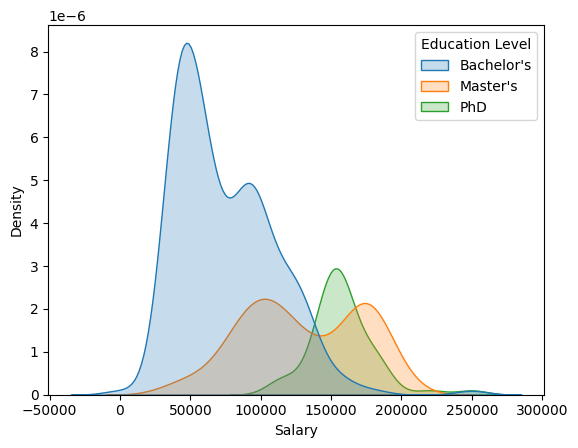

In [11]:
sns.kdeplot(data=df, x="Salary", hue="Education Level", fill=True)
plt.show

Gender
Male      194
Female    179
Name: count, dtype: int64


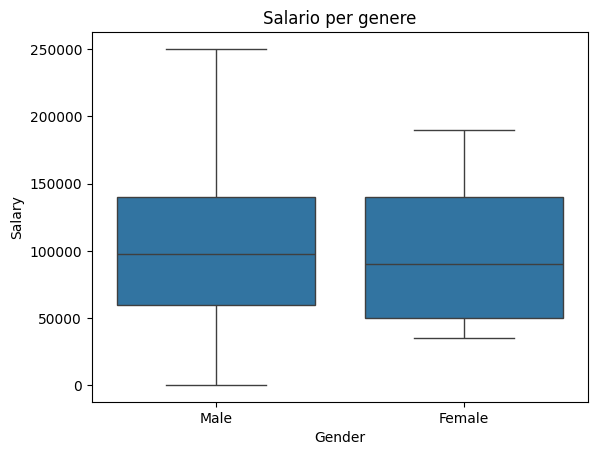

In [12]:
# Controllo frequenze
print(df['Gender'].value_counts())

# Boxplot per capire la relazione con il salario
sns.boxplot(x='Gender', y='Salary', data=df)
plt.title("Salario per genere")
plt.show()

Da questo grafico vediamo che:
- La mediana degli uomo è leggermente più alta rispetto alle donne
- Gli uomini mostrano valori massimi più elevati 
- Le distribuzion si sovrappongono molto, non c'è una separazione netta
--> non possiamo quindi dire che gli uomini guadagnano di più o se c'è un gender gap solo con questi dati, perché potrebbero esserci fattori nascosti come il ruolo, l'esprerienza...

In [13]:
#sns.boxplot(data=df, x="Education Level", y="Salary", hue="Gender")

## Conclusioni EDA
- Il salario ha una distribuzione [aggiungi osservazione: es. leggermente asimmetrica]  
- Le variabili più correlate con il salario sono [...]  
- Alcune categorie hanno pochi esempi, considerare se unirle o eliminarle  
- Ci sono valori mancanti in [...] (se presenti)

In [14]:
df.head()


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
